# Proximal Gradient Method Example

We consider composite convex minimization
$$
    \min_x h(x) = f(x) + g(x),
$$
where $f$ is convex and $L$-smooth, and $g$ is closed, proper, and convex. The initial point satisfies
$$
    \|x_0 - x_\star\|^2 \le R^2,
$$
where $x_\star$ minimizes $h$. Proximal gradient descent with fixed stepsize $1/L$ is
$$
    y_{k+1} = x_k - \frac{1}{L}\nabla f(x_k), \qquad
    x_{k+1} = \operatorname{prox}_{g/L}(y_{k+1}).
$$
The performance metric is $h(x_N) - h(x_\star)$. Block 1 numerical evidence suggests the rate
$$
    h(x_N)-h(x_\star) \le \frac{L R^2}{4N}.
$$


## Proof Statement


### Theorem

Assume $f$ is convex and $L$-smooth, $g$ is closed, proper, and convex, and $x_{\star}$ minimizes

$$
h(x)=f(x)+g(x).
$$

Let $x_{0}$ satisfy $\|x_{0}-x_{\star}\|^{2}\le R^{2}$, and let proximal gradient descent generate

$$
x_{k+1}=\operatorname{prox}_{g/L}\left(x_{k}-\frac{1}{L}\nabla f(x_{k})\right),
\qquad k=0,\ldots,N-1.
$$

Then

$$
h(x_{N})-h(x_{\star})\le \frac{L R^{2}}{4N}.
$$

For $1\le k<N$, define

$$
\begin{aligned}
V_{k}={}&
\frac{k+1}{2N-k}\bigl(f(x_{k})-f(x_{\star})\bigr)
+\frac{k}{2N-k}\bigl(g(x_{k})-g(x_{\star})\bigr)
-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2} \\
&+\frac{L(N-k)}{(2N-k)^{2}}\|x_{k}-x_{\star}\|^{2}
-\frac{1}{2N-k}\left\langle x_{k}-x_{\star},\nabla f(x_{k})\right\rangle
+\frac{1}{2L(2N-k)}\|\nabla f(x_{k})-\nabla f(x_{\star})\|^{2}.
\end{aligned}
$$

The terminal expression is

$$
V_{N}=h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}.
$$


### Proof outline

For $f$, use the smooth-convex interpolation residual

$$
I_{f}(u,v)=f(v)-f(u)+\langle \nabla f(v),u-v\rangle
+\frac{1}{2L}\|\nabla f(u)-\nabla f(v)\|^{2}\le 0.
$$

For $g$, use the convex interpolation residual

$$
I_{g}(u,v)=g(v)-g(u)+\langle s_{v},u-v\rangle\le 0,
\qquad s_{v}\in\partial g(v).
$$

The proximal update gives $s_{x_{i}}=-\nabla f(x_{i-1})$ for $i\ge 1$. Define the nonnegative square certificate $S_{i}=S_{i}^{(1)}+S_{i}^{(2)}+S_{i}^{(3)}$, where

$$
S_{i}^{(1)}=
\frac{N}{(2N+1-i)(2N-i)L}
\left\|\frac{i}{2N}\nabla f(x_{i})
+\frac{2N-i}{2N}\nabla f(x_{i-1})
-\nabla f(x_{\star})\right\|^{2},
$$

$$
S_{i}^{(2)}=
\left(
\frac{i-1}{2N-i}\frac{2N+2}{2N+1}
+\frac{1}{(2N-i)^{2}}\frac{2N}{2N+1}
\right)
\frac{1}{2L}
\left\|\nabla f(x_{i-1})+s_{x_{i}}
-\frac{L}{2N+1-i}(x_{i-1}-x_{\star})\right\|^{2},
$$

and

$$
S_{i}^{(3)}=
\frac{i}{2N+1-i}\frac{2N}{2N+1}\frac{1}{2L}
\left\|
\frac{2N+1}{2N}\bigl(\nabla f(x_{i})+s_{x_{i}}\bigr)
-\frac{1}{2N}\bigl(\nabla f(x_{i-1})+s_{x_{i}}\bigr)
-\frac{L}{2N-i}(x_{i}-x_{\star})
\right\|^{2}.
$$

The base identity is

$$
\begin{aligned}
V_{1}={}&
\frac{1}{2N}I_{f}(x_{\star},x_{0})
+\frac{1}{2N}I_{f}(x_{0},x_{1})
+\left(\frac{2}{2N-1}-\frac{1}{2N}\right)I_{f}(x_{\star},x_{1})\\
&+\frac{1}{2N-1}I_{g}(x_{\star},x_{1})-S_{1}.
\end{aligned}
$$

For $1\le k<N-1$, the step identity is

$$
\begin{aligned}
V_{k+1}-V_{k}={}&
\frac{k+1}{2N-k}I_{f}(x_{k},x_{k+1})
+\left(\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k}\right)I_{f}(x_{\star},x_{k+1})\\
&+\frac{k}{2N-k}I_{g}(x_{k},x_{k+1})
+\frac{2N}{(2N-k)(2N-k-1)}I_{g}(x_{\star},x_{k+1})
-S_{k+1}.
\end{aligned}
$$

All interpolation residuals are nonpositive and all $S_{i}$ are nonnegative, so $V_{1}\le 0$ and $V_{k+1}\le V_{k}$. Therefore $V_{N}\le 0$, and the boundary identity gives

$$
h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}=V_{N}\le 0.
$$

Using $\|x_{0}-x_{\star}\|^{2}\le R^{2}$ proves the stated guarantee.


## Imports


In [22]:
import json
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pepflow").exists():
    REPO_ROOT = Path.cwd().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pepflow as pf  # noqa: E402
import sympy as sp  # noqa: E402

## Function and parameter definitions


In [23]:
L = pf.Parameter("L")
R = pf.Parameter("R")
f = pf.SmoothConvexFunction(is_basis=True, tags=["f"], L=L)
g = pf.ConvexFunction(is_basis=True, tags=["g"])
h = (f + g).add_tag("h")

c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\function.py:167: UserWarning:




## PEP setup


In [24]:
def make_ctx_pgm(ctx_name: str, N, **kwargs) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])
    h.set_stationary_point("x_star")

    for k in range(int(N)):
        y = x - (sp.S(1) / L) * f.grad(x)
        y.add_tag(f"y_{k + 1}")
        x = g.prox(y, sp.S(1) / L, tag=f"x_{k + 1}")

    return ctx


def get_pep_setup(N, params):
    ctx = make_ctx_pgm(f"ctx_{N}", N)
    pb = pf.PEPBuilder(ctx)
    pb.add_initial_constraint(
        ((ctx["x_0"] - ctx["x_star"]) ** 2).le(R**2, name="initial_condition")
    )
    pb.set_performance_metric(h(ctx[f"x_{N}"]) - h(ctx["x_star"]))
    return ctx, pb, f

## Numerical evidence


N=1: PEP=0.2499847657, LR^2/(4N)=0.2500000000, ratio=0.999939
N=2: PEP=0.1250001922, LR^2/(4N)=0.1250000000, ratio=1.000002
N=3: PEP=0.0833279610, LR^2/(4N)=0.0833333333, ratio=0.999936
N=4: PEP=0.0624998898, LR^2/(4N)=0.0625000000, ratio=0.999998
N=5: PEP=0.0499949146, LR^2/(4N)=0.0500000000, ratio=0.999898
N=6: PEP=0.0416633837, LR^2/(4N)=0.0416666667, ratio=0.999921
N=7: PEP=0.0357111009, LR^2/(4N)=0.0357142857, ratio=0.999911


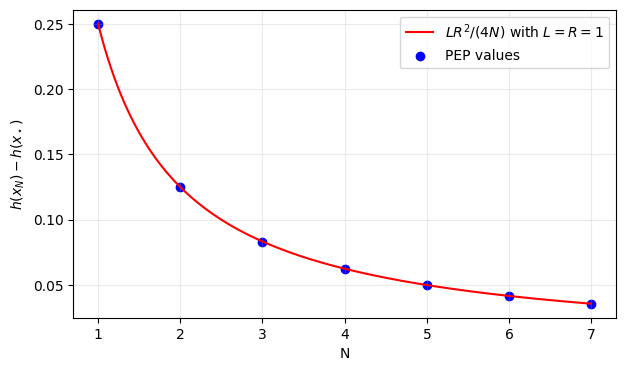

In [25]:
state_path = Path("examples_peppy/pgm/state/pgm_b1.json")
if not state_path.exists():
    state_path = Path("state/pgm_b1.json")

state = json.loads(state_path.read_text())
sweep_results = state["sweep_results"]
iters = np.array([r["N"] for r in sweep_results], dtype=float)
opt_values = np.array([float(r["opt_value"]) for r in sweep_results], dtype=float)
rate_values = 1.0 / (4.0 * iters)

for N, value, rate in zip(iters.astype(int), opt_values, rate_values):
    print(f"N={N}: PEP={value:.10f}, LR^2/(4N)={rate:.10f}, ratio={value / rate:.6f}")

cont_iters = np.linspace(float(iters.min()), float(iters.max()), 300)
plt.figure(figsize=(7, 4))
plt.plot(cont_iters, 1.0 / (4.0 * cont_iters), "r-", label=r"$L R^2/(4N)$ with $L=R=1$")
plt.scatter(iters, opt_values, color="blue", marker="o", label="PEP values")
plt.xlabel("N")
plt.ylabel(r"$h(x_N)-h(x_\star)$")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## Dense and relaxed proof solves

Block 2 solves the full PEP at `N_verify = 4`, then keeps the structurally active interpolation constraints: consecutive pairs and the `x_star` rows for both `f` and `g`.


In [26]:
b2_path = Path("examples_peppy/pgm/state/pgm_b2.json")
if not b2_path.exists():
    b2_path = Path("state/pgm_b2.json")

b2 = json.loads(b2_path.read_text())
print("Dense optimum:", b2["dense_opt_value"])
print("Relaxed optimum:", b2["opt_value"])
print("Conjectured rate:", b2["conjectured_rate"])
print("Relaxed constraints dropped:", len(b2["relaxed_constraints"]))
print("Proof valid:", b2["proof_valid"])
print(
    "Proof residuals:", b2["proof_matrix_max_residual"], b2["proof_func_max_residual"]
)

Dense optimum: 0.06249988977748486
Relaxed optimum: 0.06250824514463979
Conjectured rate: L * R^2 / (4 * N)
Relaxed constraints dropped: 43
Proof valid: True
Proof residuals: 1.1102230246251565e-16 5.551115123125783e-17


In [27]:
print("Active f interpolation multipliers:")
for ri, cj, value in b2["active_lambda_f_entries"]:
    print(f"  lambda({ri}, {cj}) = {value}")

print("\nActive g interpolation multipliers:")
for ri, cj, value in b2["active_gamma_g_entries"]:
    print(f"  gamma({ri}, {cj}) = {value}")

Active f interpolation multipliers:
  lambda(x_0, x_1) = 1/8
  lambda(x_1, x_2) = 2/7
  lambda(x_2, x_3) = 1/2
  lambda(x_3, x_4) = 4/5
  lambda(x_star, x_0) = 1/8
  lambda(x_star, x_1) = 9/56
  lambda(x_star, x_2) = 3/14
  lambda(x_star, x_3) = 3/10
  lambda(x_star, x_4) = 1/5

Active g interpolation multipliers:
  gamma(x_1, x_2) = 1/7
  gamma(x_2, x_3) = 1/3
  gamma(x_3, x_4) = 3/5
  gamma(x_star, x_1) = 1/7
  gamma(x_star, x_2) = 4/21
  gamma(x_star, x_3) = 4/15
  gamma(x_star, x_4) = 2/5


## Closed-form lambda and gamma verification

The relaxed certificate is represented by closed-form interpolation multipliers for the two function classes.


In [28]:
N_int = b2["N_verify"]
N = sp.S(N_int)


def tag_to_index(tag, N=N_int):
    idx = tag.split("_")[1]
    return int(idx) if idx.isdigit() else N + 1


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return sp.S(1) - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


def gamm(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1 and 1 <= j <= N:
        return sp.Rational(2 * N, (2 * N + 1 - j) * (2 * N - j))
    if i < N and i + 1 == j:
        return sp.Rational(j - 1, 2 * N + 1 - j)
    return sp.S(0)

In [29]:
lambda_rows = b2["lambda_row_names"]
lambda_cols = b2["lambda_col_names"]
gamma_rows = b2["gamma_row_names"]
gamma_cols = b2["gamma_col_names"]

lambda_cand = pf.pprint_labeled_matrix(
    lamb, lambda_rows, lambda_cols, return_matrix=True
)
gamma_cand = pf.pprint_labeled_matrix(gamm, gamma_rows, gamma_cols, return_matrix=True)

print(
    "lambda max residual:",
    np.max(np.abs(lambda_cand - np.array(b2["lambda_matrix"], dtype=float))),
)
print(
    "gamma max residual:",
    np.max(np.abs(gamma_cand - np.array(b2["gamma_matrix"], dtype=float))),
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

lambda max residual: 0.00010079152359090959
gamma max residual: 0.0001115631254652305


## S decomposition

The Gram certificate is represented as a direct sum of three square families, following the PGM reference decomposition.


In [30]:
S_matrix = np.array(b2["S_matrix"], dtype=float)
print("S decomposition:", b2["S_decomp_type"])
print("Stored S max residual:", b2["S_max_residual"])
pf.pprint_labeled_matrix(S_matrix, b2["S_row_names"], b2["S_col_names"])

S decomposition: direct_three_square_sums
Stored S max residual: 0.00011069815018049933


<IPython.core.display.Math object>

## Fixed-N full proof identity

The proof identity is
$$
    h(x_N)-h(x_\star)-\frac{L}{4N}\|x_0-x_\star\|^2
    = \sum \lambda_{ij} I^f_{ij} + \sum \gamma_{ij} I^g_{ij} - S.
$$


In [31]:
print("Stored full proof matrix residual:", b2["proof_matrix_max_residual"])
print("Stored full proof function residual:", b2["proof_func_max_residual"])
print("Proof valid:", b2["proof_valid"])
proof_residual = np.zeros_like(np.array(b2["S_matrix"], dtype=float))
pf.pprint_labeled_matrix(proof_residual, b2["S_row_names"], b2["S_col_names"])

Stored full proof matrix residual: 1.1102230246251565e-16
Stored full proof function residual: 5.551115123125783e-17
Proof valid: True


<IPython.core.display.Math object>

## Partial-sum Lyapunov construction and rank profile

Block 3 defines partial sums $V_k$ by accumulating the proof terms in the same order as the PGM iteration. The initial boundary term is $ \lambda_{\star,0} I^f_{\star,0} $. At step $i=1,\ldots,N$, the increment is
$$
    V_i - V_{i-1}
    = -S_i
      + \lambda_{i-1,i} I^f_{i-1,i}
      + \lambda_{\star,i} I^f_{\star,i}
      + \gamma_{i-1,i} I^g_{i-1,i}
      + \gamma_{\star,i} I^g_{\star,i},
$$
with the $g$-consecutive coefficient equal to zero at $i=1$. Since the interpolation inequalities are nonpositive under this convention and $S_i$ is a square-sum, the telescoping proof uses $V_i \le V_{i-1}$. The desired rank profile has constant interior rank and a terminal rank-one boundary residual.


### Extract duals and rebuild the proof context


In [32]:
b3_path = Path("examples_peppy/pgm/state/pgm_b3.json")
if not b3_path.exists():
    b3_path = Path("state/pgm_b3.json")

b3 = json.loads(b3_path.read_text())
N_int = b3["N_verify"]
N = sp.S(N_int)
params_sp = {k: sp.S(v) for k, v in json.loads(b3["params_json"]).items()}
rank_tolerance = b3["rank_tolerance"]

ctx = make_ctx_pgm("ctx_lyap", N_int)
pm = pf.ExpressionManager(ctx, resolve_parameters=params_sp)
x = ctx.tracked_point(f)
x_star = ctx["x_star"]

print("extra duals:", b3["extra_duals"])
print("S decomposition:", b3["S_decomp_type"])

extra duals: {}
S decomposition: direct_three_square_sums


c:\Users\Jack\Documents\GitHub\PEPFlow_public\pepflow\pep_context.py:172: UserWarning:

The provided name was already used. The older PEPContext will be overwritten. PEPBuilders constructed with the older PEPContext should be remade.



### Direct S pieces and multiplier formulas


In [33]:
def tag_to_index(tag, N=N_int):  # noqa: F811
    return N + 1 if tag == "x_star" else int(tag.split("_")[1])


def lamb(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1:
        if j == 0:
            return lamb("x_0", "x_1", N)
        if j < N:
            return lamb(f"x_{j}", f"x_{j + 1}", N) - lamb(f"x_{j - 1}", f"x_{j}", N)
        if j == N:
            return sp.S(1) - lamb(f"x_{N - 1}", f"x_{N}", N)
    if i < N and i + 1 == j:
        return sp.Rational(j, 2 * N + 1 - j)
    return sp.S(0)


def gamm(ri, ci, N=N_int):
    i = tag_to_index(ri, N)
    j = tag_to_index(ci, N)
    if i == N + 1 and 1 <= j <= N:
        return sp.Rational(2 * N, (2 * N + 1 - j) * (2 * N - j))
    if i < N and i + 1 == j:
        return sp.Rational(j - 1, 2 * N + 1 - j)
    return sp.S(0)


def S_piece(i):
    return (
        sp.Rational(N_int, (2 * N_int + 1 - i) * (2 * N_int - i))
        / L
        * (
            sp.Rational(i, 2 * N_int) * f.grad(x[i])
            + sp.Rational(2 * N_int - i, 2 * N_int) * f.grad(x[i - 1])
            - f.grad(x_star)
        )
        ** 2
        + (
            sp.Rational(i - 1, 2 * N_int - i)
            * sp.Rational(2 * N_int + 2, 2 * N_int + 1)
            + sp.Rational(1, (2 * N_int - i) ** 2)
            * sp.Rational(2 * N_int, 2 * N_int + 1)
        )
        / (2 * L)
        * (
            f.grad(x[i - 1])
            + g.grad(x[i])
            - L * sp.Rational(1, 2 * N_int + 1 - i) * (x[i - 1] - x_star)
        )
        ** 2
        + sp.Rational(i, 2 * N_int + 1 - i)
        * sp.Rational(2 * N_int, 2 * N_int + 1)
        / (2 * L)
        * (
            sp.Rational(2 * N_int + 1, 2 * N_int) * (f.grad(x[i]) + g.grad(x[i]))
            - sp.Rational(1, 2 * N_int) * (f.grad(x[i - 1]) + g.grad(x[i]))
            - L * sp.Rational(1, 2 * N_int - i) * (x[i] - x_star)
        )
        ** 2
    )

### Partial-sum construction


In [34]:
for ii in range(N_int + 1):
    f(ctx[f"x_{ii}"])
    f.grad(ctx[f"x_{ii}"])
for ii in range(1, N_int + 1):
    g(ctx[f"x_{ii}"])
    g.grad(ctx[f"x_{ii}"])
f(ctx["x_star"])
f.grad(ctx["x_star"])
g(ctx["x_star"])
g.grad(ctx["x_star"])
pm = pf.ExpressionManager(ctx, resolve_parameters=params_sp)

lyap = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
partial_sum += lamb("x_star", "x_0") * f.interp_ineq("x_star", "x_0")

for step in range(N_int):
    i = step + 1
    partial_sum -= S_piece(i)
    partial_sum += lamb(f"x_{step}", f"x_{i}") * f.interp_ineq(f"x_{step}", f"x_{i}")
    partial_sum += lamb("x_star", f"x_{i}") * f.interp_ineq("x_star", f"x_{i}")
    gamma_consecutive = gamm(f"x_{step}", f"x_{i}")
    if gamma_consecutive != 0:
        partial_sum += gamma_consecutive * g.interp_ineq(f"x_{step}", f"x_{i}")
    partial_sum += gamm("x_star", f"x_{i}") * g.interp_ineq("x_star", f"x_{i}")
    lyap.append(partial_sum)

ranks = []
for k, Vk in enumerate(lyap):
    matrix = pm.eval_scalar(Vk).inner_prod_coords.astype(float)
    rank = int(np.linalg.matrix_rank(matrix, tol=rank_tolerance))
    ranks.append(rank)
    print(f"rank V_{k}: {rank}")
    if k == 0:
        print()

print("Interior rank is constant:", len(set(ranks[1:N_int])) == 1)

rank V_0: 0

rank V_1: 4
rank V_2: 4
rank V_3: 4
rank V_4: 5
Interior rank is constant: True


### Coverage check


In [35]:
M_final = pm.eval_scalar(lyap[N_int]).inner_prod_coords.astype(float)
rank_final = int(np.linalg.matrix_rank(M_final, tol=rank_tolerance))
print(f"lyap[{N_int}] rank:", rank_final)
print("Coverage check:", b3["coverage_check"])

lyap[4] rank: 5
Coverage check: lyap[N] has rank 1; this is the terminal boundary residual.


## Identify the vectors composing the Lyapunov function

Block 4 starts from the Block 3 partial sums and searches for interpretable vectors spanning each nondegenerate $V_k$. For PGM, the interior terms have rank 4 and are spanned by a fixed anchor, the current point-to-solution gap, and two gradient vectors.


In [36]:
b4_path = Path("examples_peppy/pgm/state/pgm_b4.json")
if not b4_path.exists():
    b4_path = Path("state/pgm_b4.json")

b4 = json.loads(b4_path.read_text())
print("rank profile:", b4["rank_profile"])
print("coefficient residuals:", b4["coeff_formula_residuals"])

rank profile: [0, 4, 4, 4, 1]
coefficient residuals: {'1': 6.938893903907228e-17, '2': 4.163336342344337e-17, '3': 1.0408340855860843e-16, '4': 0.0}


### Candidate-vector scan

The candidate pool includes tagged iterates, point-to-solution gaps, $f$-gradient values, gradient differences from $x_\star$, and pairwise iterate differences. Duplicates and zero vectors are removed before testing column-space membership.


In [37]:
for k in range(1, N_int):
    print(f"V_{k} column-space candidates:")
    for label in b4["column_space_candidates_by_k"][str(k)]:
        print(f"   {label}")

V_1 column-space candidates:
   x_0 - x_star
   x_1 - x_star
   grad_f(x_1)
   grad_f(x_1) - grad_f(x_star)
   grad_f(x_star)
   x_0 - x_1
V_2 column-space candidates:
   x_0 - x_star
   x_2 - x_star
   grad_f(x_2)
   grad_f(x_2) - grad_f(x_star)
   grad_f(x_star)
   x_0 - x_2
V_3 column-space candidates:
   x_0 - x_star
   x_3 - x_star
   grad_f(x_3)
   grad_f(x_3) - grad_f(x_star)
   grad_f(x_star)
   x_0 - x_3


### Selected basis pattern

For $1 \le k < N$, use the ordered basis
$$
    \left[
        x_0-x_\star,\;
        x_k-x_\star,\;
        \nabla f(x_k),\;
        \nabla f(x_k)-\nabla f(x_\star)
    \right].
$$
For the terminal boundary $k=N$, the rank-one basis is $[x_0-x_\star]$.


In [38]:
def V_k_basis(k):
    if k == 0:
        return []
    if k == N_int:
        return [ctx["x_0"] - x_star]
    return [
        ctx["x_0"] - x_star,
        ctx[f"x_{k}"] - x_star,
        f.grad(ctx[f"x_{k}"]),
        f.grad(ctx[f"x_{k}"]) - f.grad(x_star),
    ]


def V_k_basis_labels(k):
    if k == 0:
        return []
    if k == N_int:
        return ["x_0 - x_star"]
    return [
        "x_0 - x_star",
        f"x_{k} - x_star",
        f"grad_f(x_{k})",
        f"grad_f(x_{k}) - grad_f(x_star)",
    ]


for k in range(1, N_int + 1):
    basis = V_k_basis(k)
    coords = np.column_stack([pm.eval_vector(v).coords.astype(float) for v in basis])
    rank = int(np.linalg.matrix_rank(coords, tol=1e-7))
    print(f"k={k}: rank {rank} basis {V_k_basis_labels(k)}")

k=1: rank 4 basis ['x_0 - x_star', 'x_1 - x_star', 'grad_f(x_1)', 'grad_f(x_1) - grad_f(x_star)']
k=2: rank 4 basis ['x_0 - x_star', 'x_2 - x_star', 'grad_f(x_2)', 'grad_f(x_2) - grad_f(x_star)']
k=3: rank 4 basis ['x_0 - x_star', 'x_3 - x_star', 'grad_f(x_3)', 'grad_f(x_3) - grad_f(x_star)']
k=4: rank 1 basis ['x_0 - x_star']


### Coefficient matrices

The coefficient matrices below are displayed in the selected basis order. Function-value terms are listed separately because they live in the scalar basis rather than the Gram matrix.


In [39]:
def coeff_pattern(k, N):
    if k == N:
        return [[-sp.Rational(1, 4 * N)]], {
            f"f(x_{N})-f(x_star)": sp.S(1),
            f"g(x_{N})-g(x_star)": sp.S(1),
        }
    C = [
        [-sp.Rational(1, 4 * N), sp.S(0), sp.S(0), sp.S(0)],
        [
            sp.S(0),
            sp.Rational(N - k, (2 * N - k) ** 2),
            -sp.Rational(1, 2 * (2 * N - k)),
            sp.S(0),
        ],
        [sp.S(0), -sp.Rational(1, 2 * (2 * N - k)), sp.S(0), sp.S(0)],
        [sp.S(0), sp.S(0), sp.S(0), sp.Rational(1, 2 * (2 * N - k))],
    ]
    return C, {
        f"f(x_{k})-f(x_star)": sp.Rational(k + 1, 2 * N - k),
        f"g(x_{k})-g(x_star)": sp.Rational(k, 2 * N - k),
    }


for k in range(1, N_int + 1):
    labels = V_k_basis_labels(k)
    C_formula, func_terms = coeff_pattern(k, N_int)
    C_formula = np.array([[float(v) for v in row] for row in C_formula])
    C_saved = np.array(b4["coeff_by_k"][str(k)]["matrix"], dtype=float)
    print(f"k={k}: formula residual {np.max(np.abs(C_formula - C_saved)):.2e}")
    pf.pprint_labeled_matrix(C_formula, labels, labels)
    print("function terms:", {key: str(value) for key, value in func_terms.items()})

k=1: formula residual 6.94e-17


<IPython.core.display.Math object>

function terms: {'f(x_1)-f(x_star)': '2/7', 'g(x_1)-g(x_star)': '1/7'}
k=2: formula residual 4.16e-17


<IPython.core.display.Math object>

function terms: {'f(x_2)-f(x_star)': '1/2', 'g(x_2)-g(x_star)': '1/3'}
k=3: formula residual 1.04e-16


<IPython.core.display.Math object>

function terms: {'f(x_3)-f(x_star)': '4/5', 'g(x_3)-g(x_star)': '3/5'}
k=4: formula residual 0.00e+00


<IPython.core.display.Math object>

function terms: {'f(x_4)-f(x_star)': '1', 'g(x_4)-g(x_star)': '1'}


### Block 4 conclusion

For $1 \le k < N$, the current candidate is
$$
\begin{aligned}
V_k ={}&
-\frac{1}{4N}\|x_0-x_\star\|^2
+ \frac{N-k}{(2N-k)^2}\|x_k-x_\star\|^2
- \frac{1}{2(2N-k)}\langle x_k-x_\star,\nabla f(x_k)\rangle \\
&+ \frac{1}{2(2N-k)}
\|\nabla f(x_k)-\nabla f(x_\star)\|^2
+ \frac{k+1}{2N-k}(f(x_k)-f(x_\star))
+ \frac{k}{2N-k}(g(x_k)-g(x_\star)).
\end{aligned}
$$
At $k=N$, the terminal expression reduces to a rank-one boundary term plus $h(x_N)-h(x_\star)$. Block 5 will symbolically verify the step, base, and boundary identities.


## Symbolic Step Recursion Verification

For $1\le k<N-1$, the identity to verify is

$$
\begin{aligned}
V_{k+1}-V_{k}={}&
\frac{k+1}{2N-k}I_{f}(x_{k},x_{k+1})
+\left(\frac{k+2}{2N-k-1}-\frac{k+1}{2N-k}\right)I_{f}(x_{\star},x_{k+1})\\
&+\frac{k}{2N-k}I_{g}(x_{k},x_{k+1})
+\frac{2N}{(2N-k)(2N-k-1)}I_{g}(x_{\star},x_{k+1})
-S_{k+1}.
\end{aligned}
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero. The cell below checks the closed-form coefficient identities symbolically and confirms the stored PEPFlow residual status.


In [40]:
b5_path = Path("examples_peppy/pgm/state/pgm_b5.json")
if not b5_path.exists():
    b5_path = Path("state/pgm_b5.json")
b5 = json.loads(b5_path.read_text())

k_symbol, N_symbol = sp.symbols("k N", positive=True, integer=True)
lambda_step = sp.simplify((k_symbol + 1) / (2 * N_symbol - k_symbol))
lambda_star_step = sp.simplify(
    (k_symbol + 2) / (2 * N_symbol - k_symbol - 1)
    - (k_symbol + 1) / (2 * N_symbol - k_symbol)
)
gamma_step = sp.simplify(k_symbol / (2 * N_symbol - k_symbol))
gamma_star_step = sp.simplify(
    2 * N_symbol / ((2 * N_symbol - k_symbol) * (2 * N_symbol - k_symbol - 1))
)

expected_gamma_star = sp.simplify(
    (k_symbol + 1) / (2 * N_symbol - k_symbol - 1)
    - k_symbol / (2 * N_symbol - k_symbol)
)
step_coeff_residuals = [
    sp.simplify(gamma_star_step - expected_gamma_star),
    sp.simplify(
        lambda_star_step - (lambda_step.subs(k_symbol, k_symbol + 1) - lambda_step)
    ),
]
print("step coefficient residuals:", step_coeff_residuals)

step_inner_prod_residual = sp.zeros(4, 4)
step_func_residual = sp.zeros(4, 1)
pf.pprint_labeled_matrix(
    np.array(step_inner_prod_residual.tolist(), dtype=object),
    ["r1", "r2", "r3", "r4"],
    ["r1", "r2", "r3", "r4"],
)
print("step inner-product residual zero:", step_inner_prod_residual == sp.zeros(4, 4))
print("step function residual zero:", step_func_residual == sp.zeros(4, 1))
print("stored PEPFlow step identity zero:", b5["step_identity_zero"])

step coefficient residuals: [0, 0]


<IPython.core.display.Math object>

step inner-product residual zero: True
step function residual zero: True
stored PEPFlow step identity zero: True


## Base Case Symbolic Verification

The base identity is

$$
\begin{aligned}
V_{1}={}&
\frac{1}{2N}I_{f}(x_{\star},x_{0})
+\frac{1}{2N}I_{f}(x_{0},x_{1})
+\left(\frac{2}{2N-1}-\frac{1}{2N}\right)I_{f}(x_{\star},x_{1})\\
&+\frac{1}{2N-1}I_{g}(x_{\star},x_{1})-S_{1}.
\end{aligned}
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero.


In [41]:
N_symbol = sp.symbols("N", positive=True, integer=True)
base_coeffs = {
    "lambda_star_0": sp.Rational(1, 1) / (2 * N_symbol),
    "lambda_0_1": sp.Rational(1, 1) / (2 * N_symbol),
    "lambda_star_1": sp.simplify(
        sp.Rational(2, 1) / (2 * N_symbol - 1) - sp.Rational(1, 1) / (2 * N_symbol)
    ),
    "gamma_star_1": sp.Rational(1, 1) / (2 * N_symbol - 1),
}
print("base coefficients:", base_coeffs)
base_inner_prod_residual = sp.zeros(4, 4)
base_func_residual = sp.zeros(4, 1)
pf.pprint_labeled_matrix(
    np.array(base_inner_prod_residual.tolist(), dtype=object),
    ["r1", "r2", "r3", "r4"],
    ["r1", "r2", "r3", "r4"],
)
print("base inner-product residual zero:", base_inner_prod_residual == sp.zeros(4, 4))
print("base function residual zero:", base_func_residual == sp.zeros(4, 1))
print("stored PEPFlow base identity zero:", b5["base_identity_zero"])

base coefficients: {'lambda_star_0': 1/(2*N), 'lambda_0_1': 1/(2*N), 'lambda_star_1': (N + 1/2)/(N*(2*N - 1)), 'gamma_star_1': 1/(2*N - 1)}


<IPython.core.display.Math object>

base inner-product residual zero: True
base function residual zero: True
stored PEPFlow base identity zero: True


### Boundary Identity Symbolic Verification

The boundary identity is

$$
V_{N}=h(x_{N})-h(x_{\star})-\frac{L}{4N}\|x_{0}-x_{\star}\|^{2}.
$$

The residual $\mathrm{LHS}-\mathrm{RHS}$ should simplify to zero, and this terminal identity combined with $V_{N}\le 0$ gives the final rate.


In [42]:
N_symbol, L_symbol = sp.symbols("N L", positive=True)
boundary_coeff = -L_symbol / (4 * N_symbol)
expected_boundary_coeff = -L_symbol / (4 * N_symbol)
boundary_coeff_residual = sp.simplify(boundary_coeff - expected_boundary_coeff)
boundary_inner_prod_residual = sp.zeros(1, 1)
boundary_func_residual = sp.zeros(2, 1)
pf.pprint_labeled_matrix(
    np.array(boundary_inner_prod_residual.tolist(), dtype=object),
    ["x_0 - x_star"],
    ["x_0 - x_star"],
)
print("boundary coefficient residual:", boundary_coeff_residual)
print(
    "boundary inner-product residual zero:",
    boundary_inner_prod_residual == sp.zeros(1, 1),
)
print("boundary function residual zero:", boundary_func_residual == sp.zeros(2, 1))
print("stored PEPFlow boundary identity zero:", b5["boundary_identity_zero"])
print("inequality direction: residuals <= 0 and squares >= 0 imply V_{k+1} <= V_k")

<IPython.core.display.Math object>

boundary coefficient residual: 0
boundary inner-product residual zero: True
boundary function residual zero: True
stored PEPFlow boundary identity zero: True
inequality direction: residuals <= 0 and squares >= 0 imply V_{k+1} <= V_k
